# Modelo convolucional 1D

Entrenamiento del modelo convolucional descrito en la memoria (apartado *Modelo convolucional 1D*).

Planteamiento de superresolución:

1. El espectro de Gaia se interpola linealmente sobre la malla de longitudes de onda de SDSS, de modo que entrada y salida quedan alineadas punto a punto.
2. Una red convolucional residual aprende la **corrección** que hay que aplicar sobre el espectro interpolado (conexión residual global), en lugar de generar el espectro completo desde cero.
3. Cada par de espectros se normaliza con la mediana del flujo de Gaia, por lo que la normalización puede deshacerse usando solo la entrada (aplicable a observaciones nuevas sin conocer el espectro de SDSS).

In [1]:
import sys

import numpy as np
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"
MODELS_DIR = SOLUTION_DIR / "models"
CNN_DIR = MODELS_DIR / "cnn"
ISPEC_DIR = SOLUTION_DIR / "lib" / "iSpec"

# 'services' está en la carpeta de este cuaderno, 'model_functions' e
# 'iSpec_functions' en 'models' e iSpec no se instala como dependencia: todos se
# importan desde su carpeta
sys.path[:0] = [str(CNN_DIR), str(MODELS_DIR), str(ISPEC_DIR)]

# Ficheros de checkpoint. Esta celda no carga datos, de modo que la recarga de
# una sesión anterior solo necesita ejecutar esta celda y la de recarga.
MODEL_PATH = CNN_DIR / "cnn_v1.keras"
HISTORY_PATH = CNN_DIR / "cnn_v1_training_history.csv"
SUMMARY_PATH = CNN_DIR / "cnn_v1_training_summary.json"
TEST_DATA_PATH = CNN_DIR / "cnn_v1_test_data.npz"

# Tamaño de lote del entrenamiento, guardado también en el resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


In [2]:
# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)
print(data.files)

Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de Gaia y SDSS
X_id_test = data["X_id_test"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

print("Gaia:", X_train.shape, "| SDSS:", y_train.shape)

Gaia: (32656, 201) | SDSS: (32656, 2666)


Normalizamos cada par de espectros con la mediana del flujo de Gaia. Como ambos flujos están en las mismas unidades y los pares con escalas incoherentes ya se descartaron en el preprocesado, el espectro de SDSS normalizado queda en una escala cercana a 1.

In [4]:
# Escala por espectro: mediana del flujo de Gaia
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

X_train_norm = X_train / X_scale_train
X_val_norm = X_val / X_scale_val
X_test_norm = X_test / X_scale_test

# El objetivo se normaliza con la misma escala que su entrada
y_train_norm = y_train / X_scale_train
y_val_norm = y_val / X_scale_val
y_test_norm = y_test / X_scale_test

Interpolamos el espectro de Gaia sobre la malla de longitudes de onda de SDSS. Esta versión interpolada es la entrada de la red y también la base sobre la que se aplica la corrección residual.

In [5]:
from services.persistence import save_test_data


def interpolate_to_sdss_grid(spectra):
    return np.stack([
        np.interp(sdss_wavelength, gaia_wavelength, spectrum)
        for spectrum in spectra
    ])

X_train_interp = interpolate_to_sdss_grid(X_train_norm)
X_val_interp = interpolate_to_sdss_grid(X_val_norm)
X_test_interp = interpolate_to_sdss_grid(X_test_norm)

print(X_train_interp.shape, "->", y_train_norm.shape)

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas
save_test_data(
    TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    y_test_norm=y_test_norm,
    X_id_test=X_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_scale_test=X_scale_test,
    X_test_interp=X_test_interp
)

2026-08-28 00:22:50.781410: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-28 00:22:51.256822: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-28 00:22:55.052003: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(32656, 2666) -> (32656, 2666)


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1_test_data.npz')

Arquitectura: capa convolucional inicial (64 filtros, núcleo 9), cuatro bloques residuales (dos convoluciones de 64 filtros con núcleo 7 y activación ELU, más un atajo) y una convolución final de un filtro que genera la corrección. La conexión residual global suma la entrada interpolada a dicha corrección.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_sdss = y_train.shape[1]


def residual_block(x, filters=64, kernel_size=7):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="elu")(x)
    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.Add()([x, shortcut])
    return layers.Activation("elu")(x)


inputs = layers.Input(shape=(n_sdss, 1))

x = layers.Conv1D(64, 9, padding="same", activation="elu")(inputs)

for _ in range(4):
    x = residual_block(x)

correction = layers.Conv1D(1, 5, padding="same")(x)

# Conexión residual global: salida = entrada interpolada + corrección
outputs = layers.Add()([inputs, correction])
outputs = layers.Reshape((n_sdss,))(outputs)

model_cnn = models.Model(inputs, outputs, name="cnn_residual_1d")

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

2026-08-28 00:23:01.107877: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_residual_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2666, 64)  │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2666, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2666, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2666, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2666, 64)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2666, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2666, 1)   │        321 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 2666, 1)   │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_9[0][0]  

 Total params: 230,849 (901.75 KB)

 Trainable params: 230,849 (901.75 KB)

 Non-trainable params: 0 (0.00 B)

El proceso deja cuatro ficheros de checkpoint en esta misma carpeta, uno por cada forma de dato, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `cnn_v1.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `cnn_v1_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre versiones del modelo. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `cnn_v1_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `cnn_v1_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores. Son **arrays** de más de cien megabytes en total, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

La lógica de guardado y recarga vive en `services/persistence.py`.


In [7]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.persistence import save_training_summary

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history = CSVLogger(HISTORY_PATH)

history = model_cnn.fit(
    X_train_interp[..., None],
    y_train_norm,
    validation_data=(X_val_interp[..., None], y_val_norm),
    epochs=50,
    batch_size=batch_size,
    callbacks=[save_best_epoch_model, early_stop, reduce_lr, save_training_history],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_cnn.save(MODEL_PATH)

training_history = history.history
save_training_summary(
    SUMMARY_PATH,
    training_history,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.0152 - mae: 0.1176 - mse: 0.0331
Epoch 1: val_loss improved from None to 0.01392, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 1639s 3s/step - loss: 0.0152 - mae: 0.1176 - mse: 0.0331 - val_loss: 0.0139 - val_mae: 0.1107 - val_mse: 0.0330 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.0134 - mae: 0.1076 - mse: 0.0295
Epoch 2: val_loss improved from 0.01392 to 0.01311, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 1616s 3s/step - loss: 0.0134 - mae: 0.1076 - mse: 0.0295 - val_

{'model': 'cnn_v1.keras',
 'history': 'cnn_v1_training_history.csv',
 'updated': '2026-08-28T04:50:41',
 'batch_size': 64,
 'epochs_completed': 10,
 'best_epoch': 10,
 'test_metrics': None}

Recarga desde el checkpoint. Esta celda recupera de los cuatro ficheros todas las variables que necesitan las celdas siguientes: el modelo, el historial, el resumen con las métricas de test y las variables del conjunto de test. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el resto del análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.


In [8]:
from services.persistence import load_checkpoint, load_test_data

model_cnn, training_history, training_summary = load_checkpoint(
    MODEL_PATH, HISTORY_PATH, SUMMARY_PATH
)

test_metrics = training_summary["test_metrics"]

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
y_test_norm = test_data["y_test_norm"]
X_id_test = test_data["X_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_scale_test = test_data["X_scale_test"]
X_test_interp = test_data["X_test_interp"]

print("Checkpoint de", training_summary["updated"])
print(
    "Épocas completadas:", training_summary["epochs_completed"],
    "| mejor época:", training_summary["best_epoch"]
)
print("Métricas de test:", test_metrics)

Checkpoint de 2026-08-28T04:50:41
Épocas completadas: 10 | mejor época: 10
Métricas de test: None


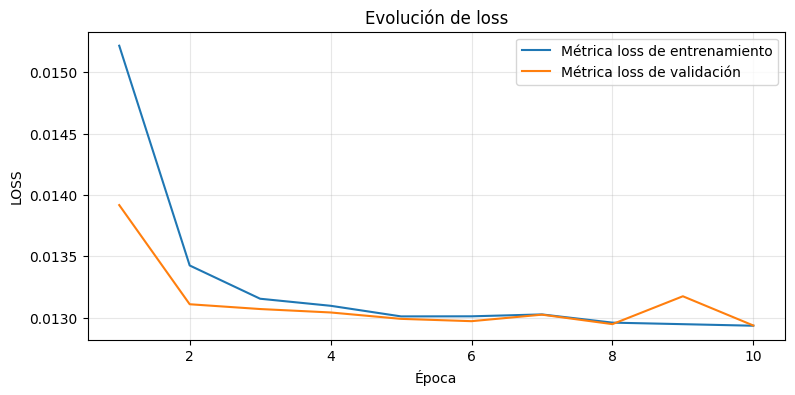

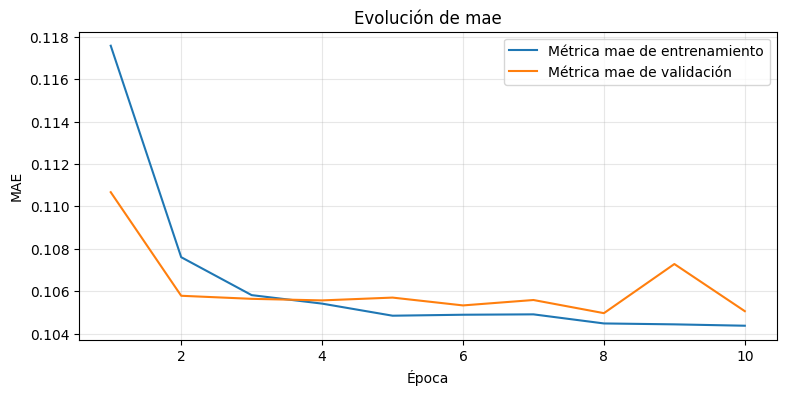

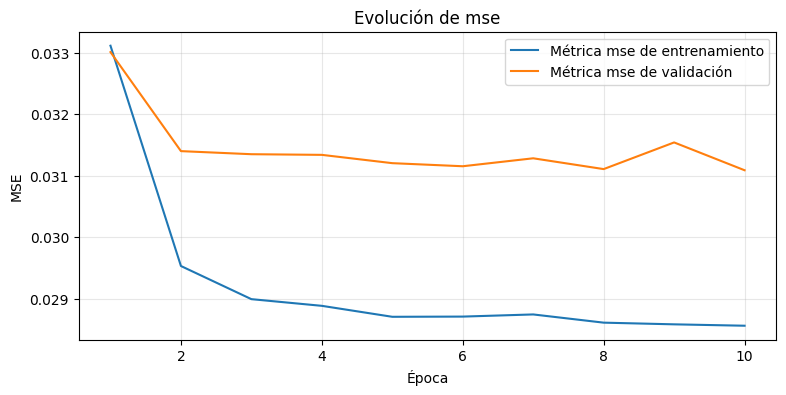

In [9]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_worst_best_predictions
)

plot_training_metrics(training_history)

In [10]:
from services.persistence import save_training_summary

test_metrics = model_cnn.evaluate(
    X_test_interp[..., None],
    y_test_norm,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    SUMMARY_PATH,
    training_history,
    test_metrics,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

print(test_metrics)

128/128 ━━━━━━━━━━━━━━━━━━━━ 43s 331ms/step - loss: 0.0128 - mae: 0.1047 - mse: 0.0272
{'loss': 0.012791167944669724, 'mae': 0.10471872985363007, 'mse': 0.027204575017094612}


In [11]:
y_pred_norm = model_cnn.predict(X_test_interp[..., None])

# Deshacemos la normalización solo con la escala de la entrada de Gaia
y_pred = y_pred_norm * X_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 44s 341ms/step


In [12]:
# Mismos objetos usados en las comparativas de la memoria

MAE:  5.4755
MSE:  115.1240
RMSE: 10.7296


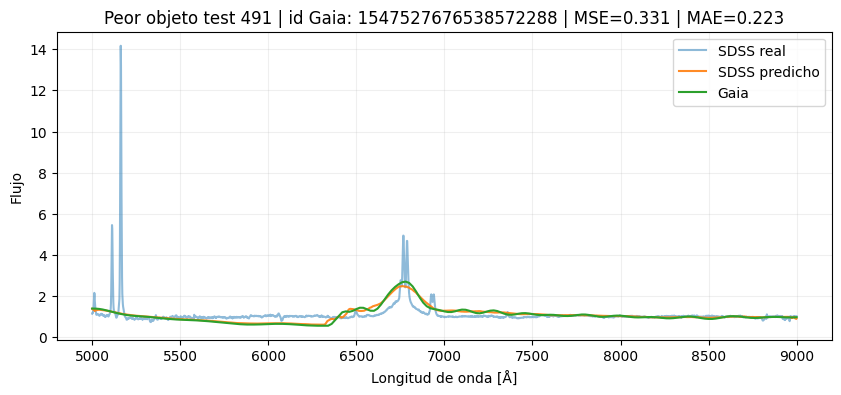

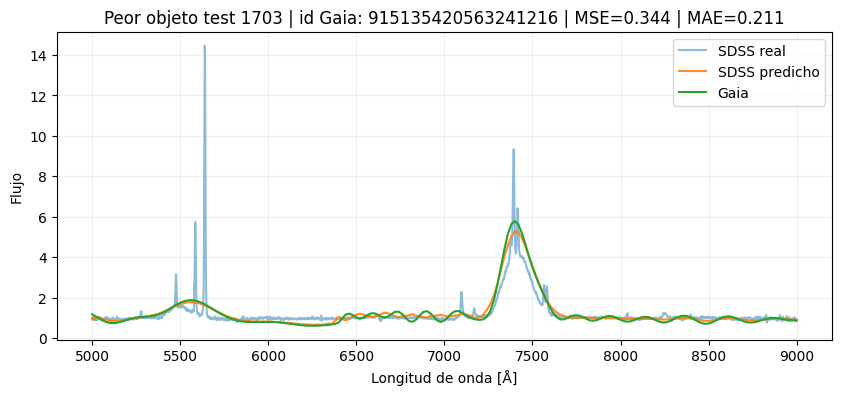

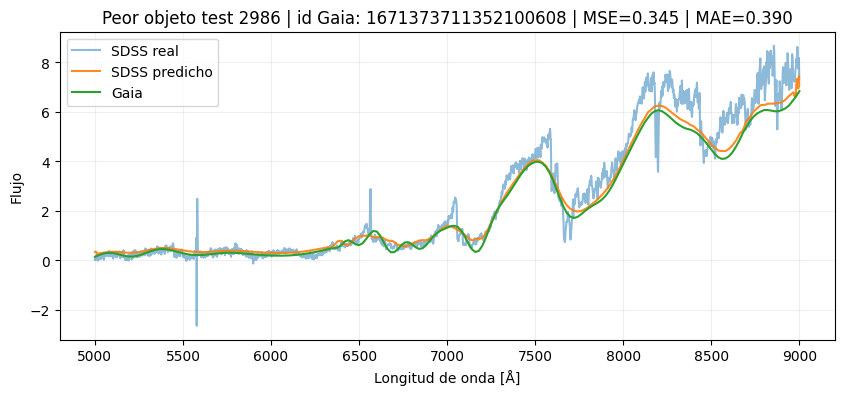

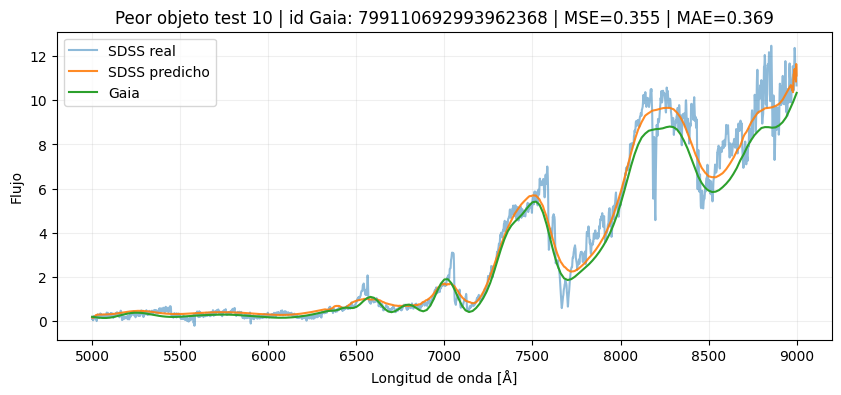

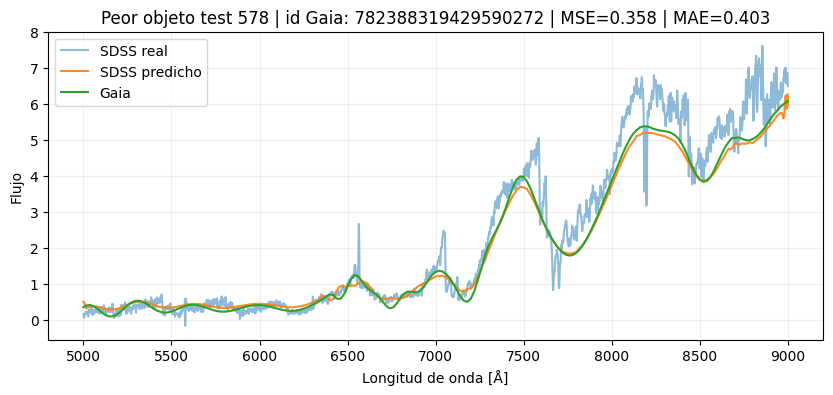

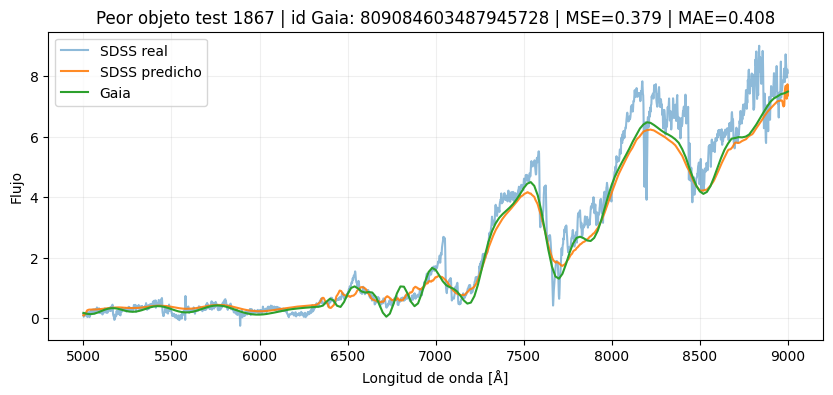

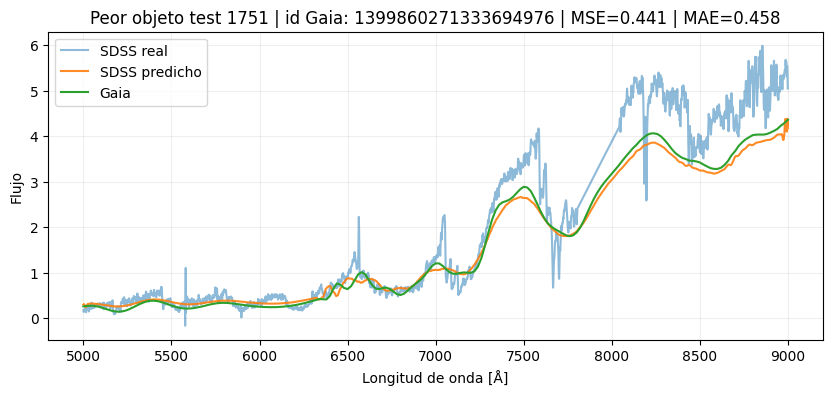

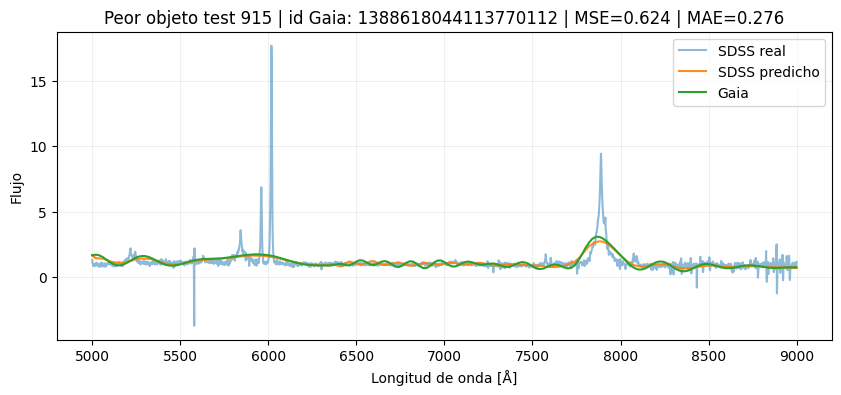

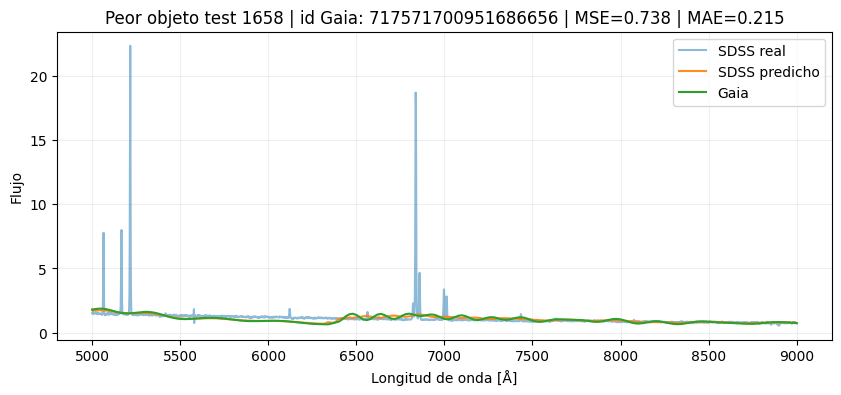

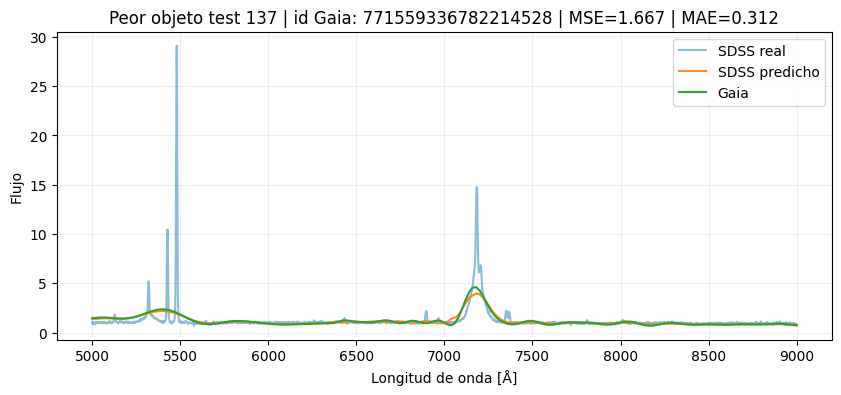

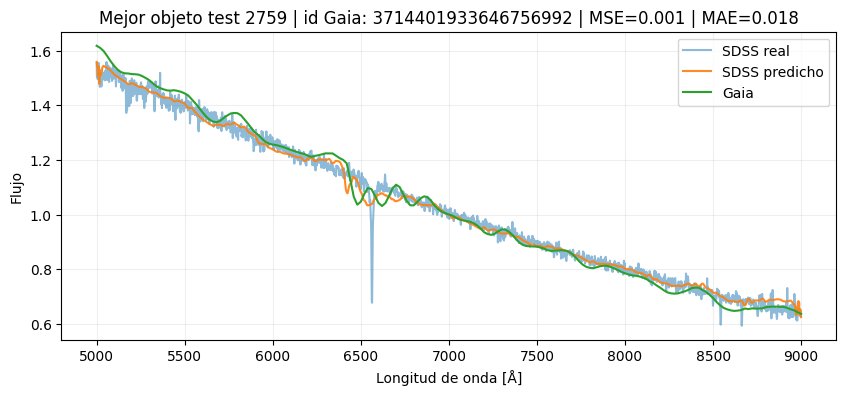

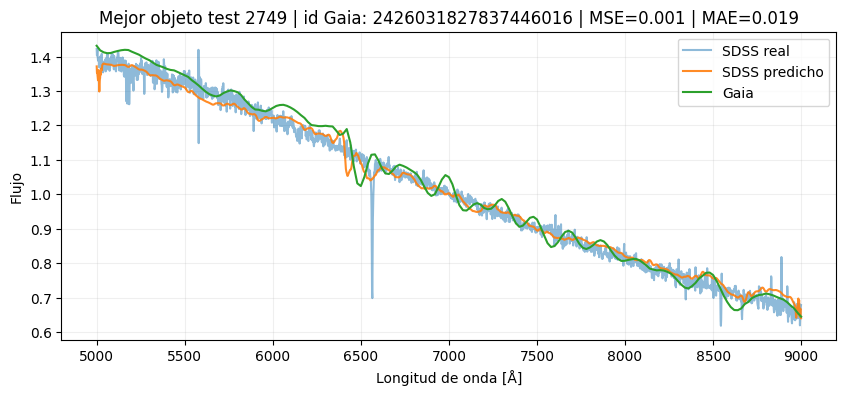

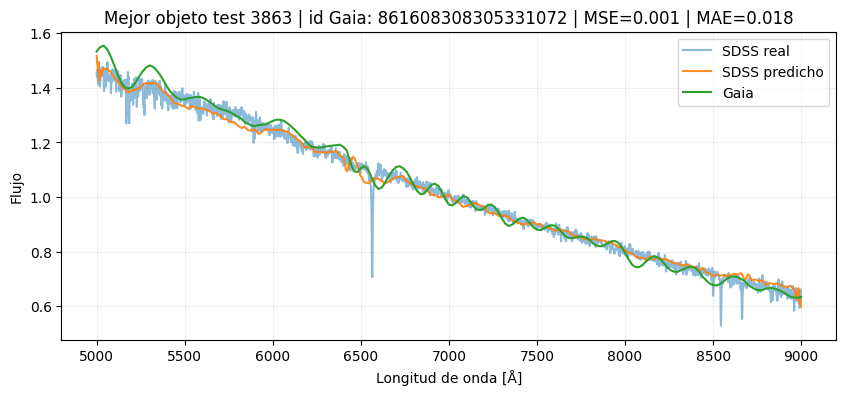

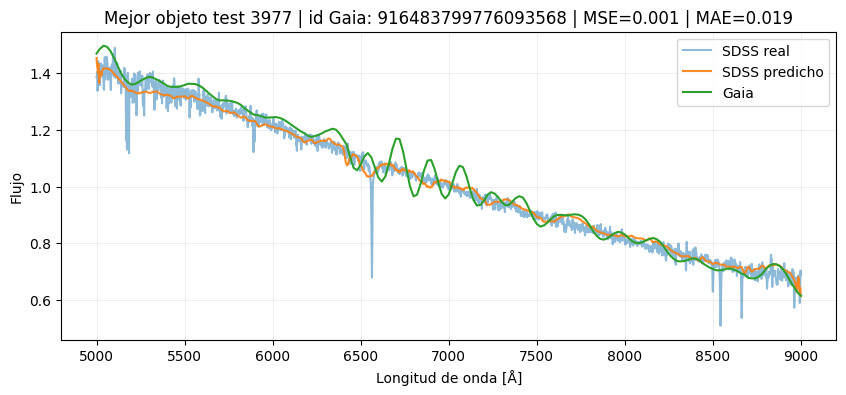

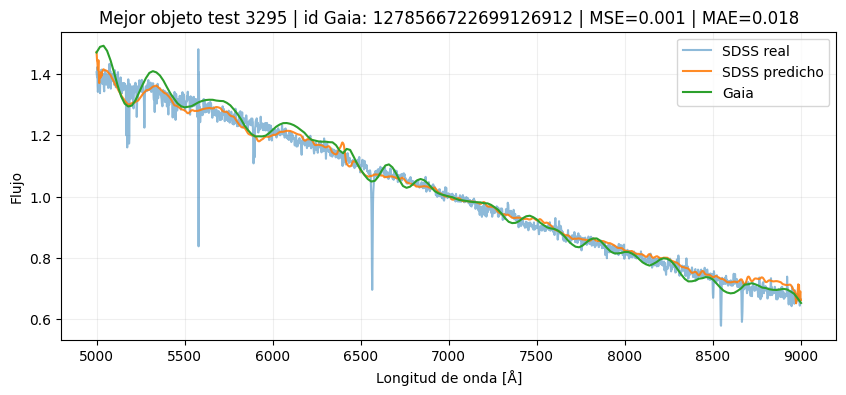

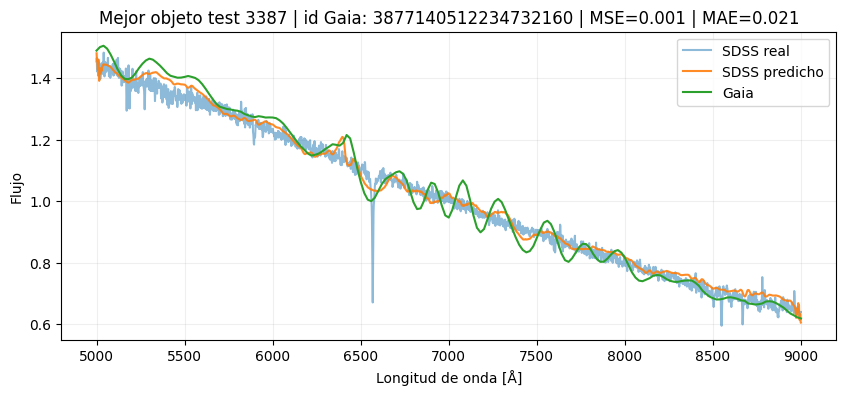

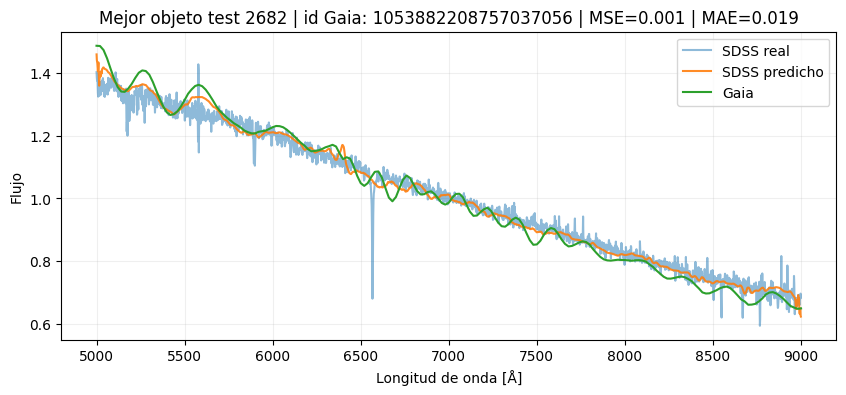

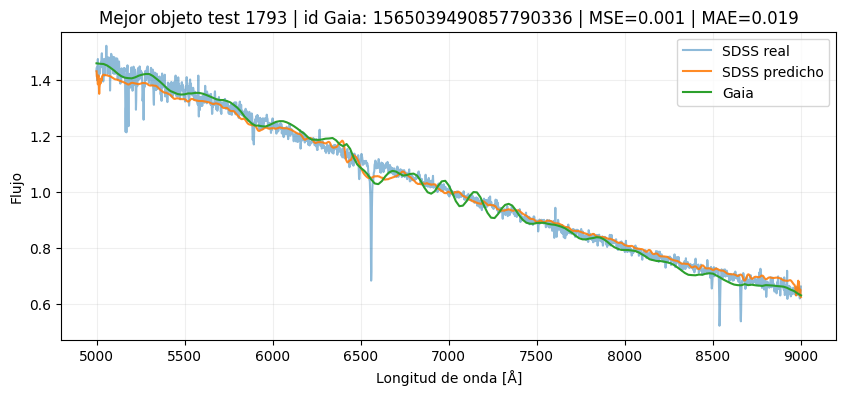

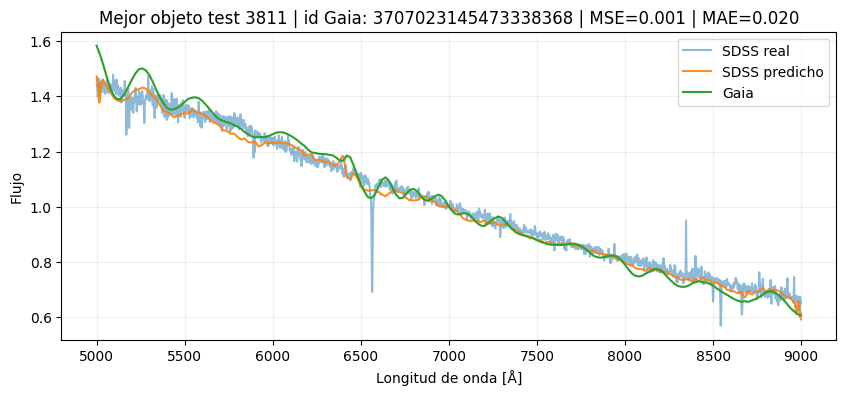

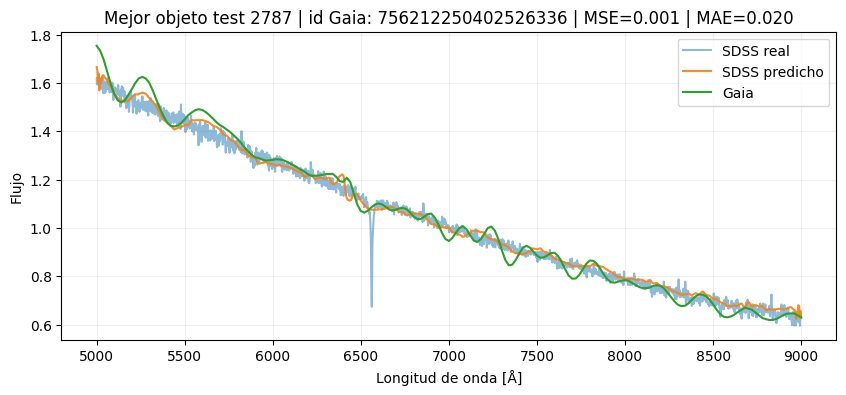

In [13]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# Comparación invariante a escala: cada espectro se normaliza con su propia
# mediana, de modo que el ranking refleja el error de forma y no el desajuste
# de calibración absoluta entre Gaia y SDSS
y_test_shape = y_test / np.nanmedian(np.abs(y_test), axis=1, keepdims=True)
y_pred_shape = y_pred / np.nanmedian(np.abs(y_pred), axis=1, keepdims=True)
X_test_shape = X_test / np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

plot_worst_best_predictions(
    y_test_shape,
    y_pred_shape,
    X_test_shape,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    10
)

In [14]:
# El modelo ya está guardado por el checkpoint; lo reescribimos por si esta
# sesión ha continuado el entrenamiento a partir de un checkpoint anterior
model_cnn.save(MODEL_PATH)

Validación física con iSpec: analizamos una muestra de espectros de test comparando los parámetros estelares (Teff, log g, [M/H]) derivados del espectro SDSS real frente a los derivados del espectro predicho por la red.

Esta celda carga el modelo guardado (`cnn_v1.keras`) y genera sus propias predicciones, por lo que no requiere haber entrenado en esta sesión: basta con ejecutar antes las celdas de preparación de datos (carga, normalización e interpolación).

128/128 ━━━━━━━━━━━━━━━━━━━━ 49s 377ms/step


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.


Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

[2026-08-28 10:00:49,010] [INFO] [continuum:__fit_continuum:637]: Resampling spectrum to wave_step: 0.25002 nm (R = 2000)
[2026-08-28 10:00:49,091] [INFO] [continuum:__median_filter:307]: Median filter with step: 5
[2026-08-28 10:00:49,099] [INFO] [continuum:__max_filter:298]: Max filter with step: 21
[2026-08-28 10:00:53,930] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:00:57,019] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:00,578] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:04,504] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:07,750] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:10,776] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:14,104] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 10:01:17,143] [INFO] [spectrum:__convolve_spectrum:789]: Spectra conv

...

[2026-08-28 15:46:55,712] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:46:58,705] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:01,748] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:04,743] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:07,701] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:10,780] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:11,477] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:12,092] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:12,813] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:47:12,832] [INFO] [continuum:__fit_continuum:637]: Resampling spectrum to wave_step: 0.25002 nm (R = 2000)
[2026-08-28 15:47:12,883] [INFO] [continuum:__median_filter:307]: Median filter with s

Error analizando espectro real


[2026-08-28 15:49:20,597] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:24,062] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:27,350] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:30,549] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:33,715] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:37,120] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:40,475] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:43,538] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:46,655] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:49,886] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:52,922] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 15:49:56,362] [INFO]

Error analizando espectro real


[2026-08-28 16:01:02,654] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:05,717] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:08,857] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:12,033] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:14,999] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:17,920] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:21,125] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:24,412] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:27,324] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:30,338] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:33,225] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-08-28 16:01:36,172] [INFO]

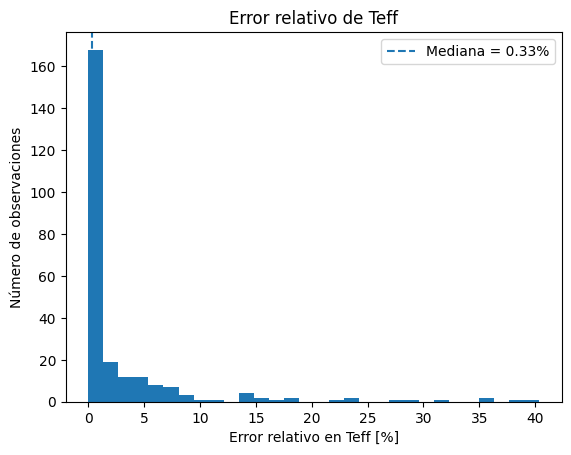

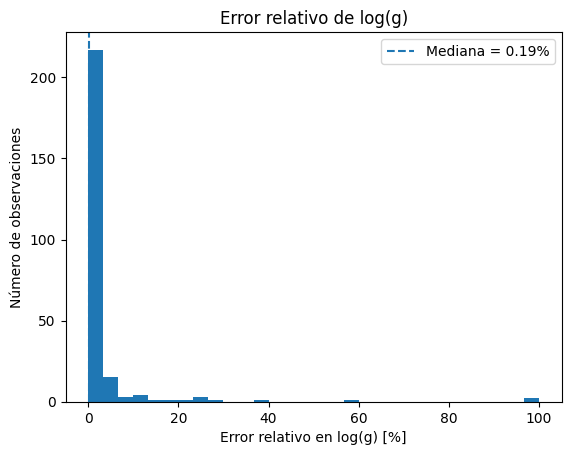

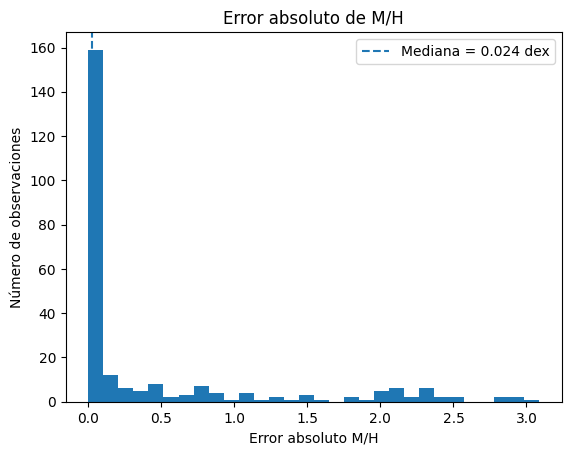

In [16]:
# Funciones de iSpec (el módulo está en 'models', ya añadido a sys.path)
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

import tensorflow as tf
from astropy.table import Table

# Cargamos el modelo entrenado y generamos las predicciones sobre test
model_cnn = tf.keras.models.load_model(MODEL_PATH)

y_pred_norm = model_cnn.predict(X_test_interp[..., None])

# Deshacemos la normalización solo con la escala de la entrada de Gaia
y_pred = y_pred_norm * X_scale_test

# Cargamos los recursos de iSpec
resources = load_ispec_resources()

# Cargamos la tabla de Gaia guardada en local
gaia_data_path = DATA_DIR / "gaia_data.ecsv"

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

# Analizamos con iSpec una muestra de espectros reales frente a predichos
results_df_cnn = analyze_sample_real_vs_pred(
    y_test,
    y_pred,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

error_df_cnn = analyze_ispec_errors(results_df_cnn)